# CNN — 1D Convolutional Neural Network for Spike Classification
Captures local temporal patterns in sliding windows of past hourly observations.
The lookback window length is included in the hyperparameter search.

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc

from shared.data_prep import (
    load_data, split_data, get_feature_cols, fit_scaler, apply_scaler,
    compute_pos_weight, random_search, SequenceDataset,
    train_model, evaluate, TARGET
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f"Device: {DEVICE}")

Device: cpu


## 1. Data Loading

In [7]:
df = load_data()
train, val, test = split_data(df)

feature_cols = get_feature_cols("CNN", df.columns.tolist())
N_FEATURES = len(feature_cols)
print(f"Features: {N_FEATURES}")
print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

# Fit scaler on training data only
scaler, cont_cols = fit_scaler(train, feature_cols)
train_s = apply_scaler(train, scaler, cont_cols)
val_s   = apply_scaler(val,   scaler, cont_cols)
test_s  = apply_scaler(test,  scaler, cont_cols)

pos_weight = compute_pos_weight(train[TARGET])
print(f"pos_weight: {pos_weight.item():.2f}")

Features: 91
Train: 33,672 | Val: 9,624 | Test: 5,543
pos_weight: 7.08


## 2. Model Architecture

In [8]:
class CNN1D(nn.Module):
    """
    1D Convolutional network for time-series classification.
    Input: (batch, lookback, n_features)
    Uses adaptive average pooling so the architecture is independent
    of the lookback window length — enabling lookback to be a hyperparameter.
    """
    def __init__(self, n_features: int, n_filters: int,
                 kernel_size: int, n_conv_layers: int, dropout: float):
        super().__init__()
        conv_blocks = []
        in_ch = n_features
        for _ in range(n_conv_layers):
            conv_blocks.extend([
                nn.Conv1d(in_ch, n_filters, kernel_size,
                          padding=kernel_size // 2),
                nn.BatchNorm1d(n_filters),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            in_ch = n_filters
        self.conv = nn.Sequential(*conv_blocks)
        # Global average pooling → (batch, n_filters) regardless of sequence length
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(n_filters, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq, features) → (batch, features, seq) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)   # (batch, n_filters)
        return self.head(x).squeeze(-1)

## 3. Hyperparameter Search
Random search with TimeSeriesSplit (5 folds). The lookback window is included in the search space. Uses SequenceDataset for each candidate lookback.

In [9]:
PARAM_GRID = {
    "lookback":      [24, 48, 72, 168],
    "n_filters":     [32, 64, 128],
    "kernel_size":   [3, 5],
    "n_conv_layers": [2, 3],
    "dropout":       [0.2, 0.3, 0.5],
    "lr":            [1e-3, 5e-4],
    "batch_size":    [64, 128, 256],
}
N_TRIALS = 15

train_val = pd.concat([train, val], ignore_index=True)

def build_fn(params, fold_train_df):
    pw        = compute_pos_weight(fold_train_df[TARGET])
    model     = CNN1D(N_FEATURES, params["n_filters"], params["kernel_size"],
                      params["n_conv_layers"], params["dropout"])
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw.to(DEVICE))
    return model, optimizer, criterion

search_results = random_search(
    PARAM_GRID, N_TRIALS, build_fn, train_val, feature_cols, DEVICE,
    use_sequences=True, n_cv_splits=5, max_epochs=25, patience=5
)

print("\n── Top 5 Configurations ──")
for r in search_results[:5]:
    print(f"  F1={r['mean_cv_f1']:.4f}  {r['params']}")


── Trial 1/15 ──  {'lookback': 72, 'n_filters': 64, 'kernel_size': 3, 'n_conv_layers': 2, 'dropout': 0.5, 'lr': 0.001, 'batch_size': 256}
  Fold 1/5  F1=0.2212
  Fold 2/5  F1=0.2602
  Fold 3/5  F1=0.4097
  Fold 4/5  F1=0.3041
  Fold 5/5  F1=0.1720
  → Mean CV F1 = 0.2735

── Trial 2/15 ──  {'lookback': 24, 'n_filters': 64, 'kernel_size': 3, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 64}
  Fold 1/5  F1=0.2586
  Fold 2/5  F1=0.3904
  Fold 3/5  F1=0.6957
  Fold 4/5  F1=0.5924
  Fold 5/5  F1=0.5179
  → Mean CV F1 = 0.4910

── Trial 3/15 ──  {'lookback': 48, 'n_filters': 128, 'kernel_size': 5, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 256}
  Fold 1/5  F1=0.2114
  Fold 2/5  F1=0.5000
  Fold 3/5  F1=0.6926
  Fold 4/5  F1=0.6168
  Fold 5/5  F1=0.5174
  → Mean CV F1 = 0.5077

── Trial 4/15 ──  {'lookback': 168, 'n_filters': 128, 'kernel_size': 5, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 256}
  Fold 1/5  F1=0.2007
  Fold 2/5  F1=0.

In [10]:
best_params = search_results[0]["params"]
print("Best hyperparameters:", best_params)

Best hyperparameters: {'lookback': 24, 'n_filters': 128, 'kernel_size': 3, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 128}


## 4. Final Training

In [11]:
# Re-fit scaler on full training set
final_scaler, final_cont_cols = fit_scaler(train, feature_cols)
train_sf = apply_scaler(train, final_scaler, final_cont_cols)
val_sf   = apply_scaler(val,   final_scaler, final_cont_cols)
test_sf  = apply_scaler(test,  final_scaler, final_cont_cols)

LB = best_params["lookback"]
BS = best_params["batch_size"]

train_ds_f = SequenceDataset(train_sf, feature_cols, LB)
val_ds_f   = SequenceDataset(val_sf,   feature_cols, LB)
test_ds_f  = SequenceDataset(test_sf,  feature_cols, LB)

train_loader_f = DataLoader(train_ds_f, batch_size=BS, shuffle=True, drop_last=True)
val_loader_f   = DataLoader(val_ds_f,   batch_size=BS * 2, shuffle=False)
test_loader_f  = DataLoader(test_ds_f,  batch_size=BS * 2, shuffle=False)

final_pw = compute_pos_weight(train[TARGET])
final_model = CNN1D(N_FEATURES, best_params["n_filters"], best_params["kernel_size"],
                    best_params["n_conv_layers"], best_params["dropout"]).to(DEVICE)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params["lr"])
final_criterion = nn.BCEWithLogitsLoss(pos_weight=final_pw.to(DEVICE))

history, best_val_f1 = train_model(
    final_model, train_loader_f, val_loader_f,
    final_optimizer, final_criterion, DEVICE,
    max_epochs=50, patience=10, checkpoint_dir=CHECKPOINT_DIR
)
print(f"\nBest validation F1: {best_val_f1:.4f}")

  Ep   1 | tr_loss=0.8565 | val_f1=0.1375 | val_auc=0.8227 | val_loss=1.3142
  Ep   2 | tr_loss=0.6408 | val_f1=0.3986 | val_auc=0.9453 | val_loss=0.4894
  Ep   3 | tr_loss=0.5077 | val_f1=0.4074 | val_auc=0.9560 | val_loss=0.4246
  Ep   4 | tr_loss=0.4714 | val_f1=0.3566 | val_auc=0.9576 | val_loss=0.4914
  Ep   5 | tr_loss=0.4560 | val_f1=0.2922 | val_auc=0.9599 | val_loss=0.6037
  Ep   6 | tr_loss=0.4421 | val_f1=0.3507 | val_auc=0.9606 | val_loss=0.4935
  Ep   7 | tr_loss=0.4332 | val_f1=0.4130 | val_auc=0.9637 | val_loss=0.4110
  Ep   8 | tr_loss=0.4264 | val_f1=0.3317 | val_auc=0.9614 | val_loss=0.5007
  Ep   9 | tr_loss=0.4200 | val_f1=0.4192 | val_auc=0.9627 | val_loss=0.3911
  Ep  10 | tr_loss=0.4140 | val_f1=0.3330 | val_auc=0.9635 | val_loss=0.4949
  Ep  11 | tr_loss=0.4014 | val_f1=0.3215 | val_auc=0.9617 | val_loss=0.5473
  Ep  12 | tr_loss=0.3988 | val_f1=0.4126 | val_auc=0.9639 | val_loss=0.4040
  Ep  13 | tr_loss=0.3884 | val_f1=0.3535 | val_auc=0.9639 | val_loss=0.4745

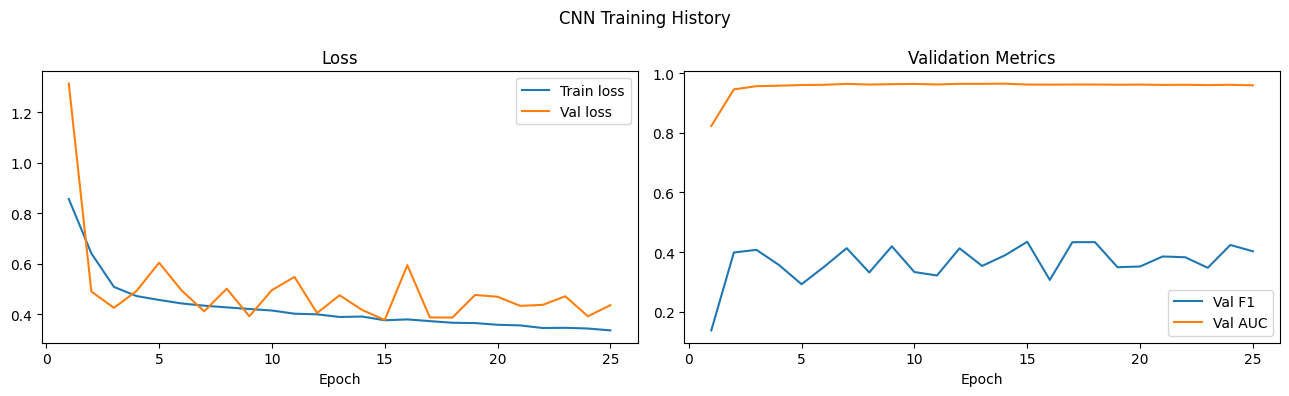

In [12]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train loss")
axes[0].plot(hist_df["epoch"], hist_df["loss"],       label="Val loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(hist_df["epoch"], hist_df["f1"],  label="Val F1")
axes[1].plot(hist_df["epoch"], hist_df["auc"], label="Val AUC")
axes[1].set_title("Validation Metrics"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("CNN Training History"); plt.tight_layout(); plt.show()

## 5. Evaluation

In [13]:
best_model = CNN1D(N_FEATURES, best_params["n_filters"], best_params["kernel_size"],
                   best_params["n_conv_layers"], best_params["dropout"]).to(DEVICE)
best_model.load_state_dict(torch.load(CHECKPOINT_DIR / "best_model.pt", map_location=DEVICE))

val_metrics  = evaluate(best_model, val_loader_f,  final_criterion, DEVICE)
test_metrics = evaluate(best_model, test_loader_f, final_criterion, DEVICE)

results_df = pd.DataFrame([val_metrics, test_metrics], index=["Validation", "Test"])
print(results_df.round(4))

              loss      f1  precision  recall     auc
Validation  0.3766  0.4344     0.2843  0.9208  0.9615
Test        0.3532  0.1661     0.0910  0.9495  0.9646


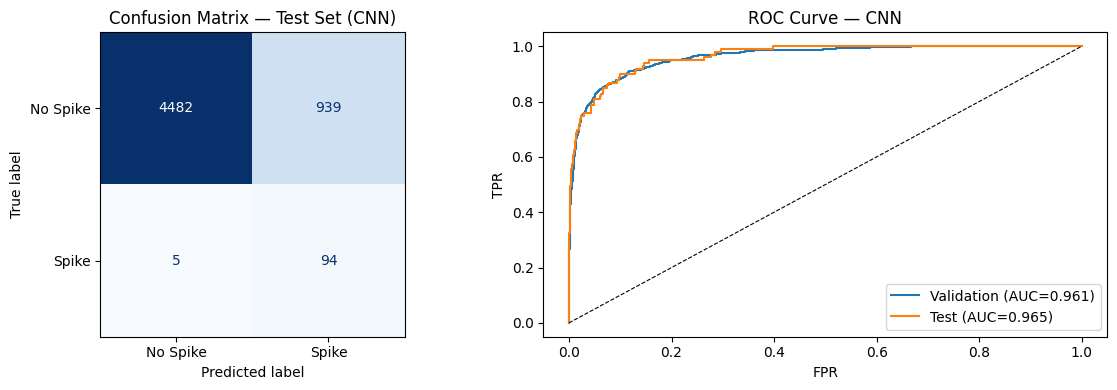


Test Classification Report:
              precision    recall  f1-score   support

    No Spike       1.00      0.83      0.90      5421
       Spike       0.09      0.95      0.17        99

    accuracy                           0.83      5520
   macro avg       0.54      0.89      0.54      5520
weighted avg       0.98      0.83      0.89      5520



In [14]:
def get_preds_probs(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            all_logits.append(model(X.to(device)).cpu())
            all_labels.append(y)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)
    probs  = 1 / (1 + np.exp(-logits))
    return labels, probs, (probs >= 0.5).astype(int)

val_labels,  val_probs,  val_preds  = get_preds_probs(best_model, val_loader_f,  DEVICE)
test_labels, test_probs, test_preds = get_preds_probs(best_model, test_loader_f, DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(test_labels, test_preds, ax=axes[0],
    display_labels=["No Spike","Spike"], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix — Test Set (CNN)")

for labels, probs, name in [(val_labels, val_probs, "Validation"),
                             (test_labels, test_probs, "Test")]:
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
axes[1].plot([0,1],[0,1],"k--",lw=0.8)
axes[1].set_title("ROC Curve — CNN"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()
plt.tight_layout(); plt.show()

print("\nTest Classification Report:")
print(classification_report(test_labels, test_preds, target_names=["No Spike","Spike"]))

## 6. Summary

In [15]:
print("=" * 50)
print("CNN FINAL RESULTS")
print("=" * 50)
print(f"Best hyperparameters : {best_params}")
print(f"\nValidation set:")
for k, v in val_metrics.items(): print(f"  {k:12s}: {v:.4f}")
print(f"\nTest set (out-of-sample):")
for k, v in test_metrics.items(): print(f"  {k:12s}: {v:.4f}")
print(f"\nCheckpoints saved to: {CHECKPOINT_DIR.resolve()}")

CNN FINAL RESULTS
Best hyperparameters : {'lookback': 24, 'n_filters': 128, 'kernel_size': 3, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 128}

Validation set:
  loss        : 0.3766
  f1          : 0.4344
  precision   : 0.2843
  recall      : 0.9208
  auc         : 0.9615

Test set (out-of-sample):
  loss        : 0.3532
  f1          : 0.1661
  precision   : 0.0910
  recall      : 0.9495
  auc         : 0.9646

Checkpoints saved to: C:\Users\Carolmon\Documents\Statistics class\Data607\Project\EnergyPriceSpikeForescastModels\CNN model\checkpoints
